In [173]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [174]:
%pip install seaborn

In [175]:
import seaborn as sns

In [176]:
filename = "Clean_Exploration_Dataset.csv"
#Load the file into the notebook and generate 10 rows of random data
geology = pd.read_csv(filename)
geology.sample(10)

,Unnamed: 0,Hole_ID,From_m,To_m,Interval_m,Au_Result,Au_Unit,Lithology,Sample_ID
172,172,BP-173,75.81,76.81,1.00,NaN,g/t,Granite,SMP-173
0,0,BP-001,56.18,96.30,40.12,NaN,g/t,Granite,SMP-1
181,181,BP-182,17.02,104.51,87.49,1.739,g/t,Granite,SMP-182
135,135,BP-136,6.11,48.48,42.37,0.141,g/t,Basalt,SMP-136
10,10,BP-011,3.09,82.31,79.22,0.194,g/t,Dolerite,SMP-11
169,169,BP-170,10.40,88.63,78.23,1.403,g/t,Dolerite,SMP-170
177,177,BP-178,3.49,58.01,54.52,2.680,g/t,NaN,SMP-178
25,25,BP-026,36.60,117.78,81.18,0.636,g/t,Basalt,SMP-26
129,129,BP-130,75.61,76.61,1.00,1.111,g/t,Granite,SMP-130
36,36,BP-037,42.12,45.69,3.57,1.511,g/t,Dolerite,SMP-37


In [177]:
#Make the columns names small letters

geology.columns = geology.columns.str.lower()

In [178]:
geology.head(2)

,unnamed: 0,hole_id,from_m,to_m,interval_m,au_result,au_unit,lithology,sample_id
0,0,BP-001,56.18,96.30,40.12,NaN,g/t,Granite,SMP-1
1,1,BP-002,12.62,142.61,129.99,NaN,g/t,Granite,SMP-2


In [179]:
#Delete the unnamed columnd
geology.drop(columns = 'unnamed: 0', inplace = True)

In [180]:
#Make the hole ID and index

geology.set_index('hole_id').head(3)

,from_m,to_m,interval_m,au_result,au_unit,lithology,sample_id
hole_id,,,,,,,
BP-001,56.18,96.30,40.12,NaN,g/t,Granite,SMP-1
BP-002,12.62,142.61,129.99,NaN,g/t,Granite,SMP-2
BP-003,24.24,109.80,85.56,1.882,g/t,Granite,SMP-3


In [181]:
#Check for missing intervals 

geology.isna().sum()

hole_id        0
from_m        10
to_m           0
interval_m    10
au_result     46
au_unit        0
lithology     18
sample_id      0
dtype: int64

In [182]:
#There are null values in the from, print all the rows with a null

from_m_null = geology[geology['from_m'].isna()]
from_m_null

,hole_id,from_m,to_m,interval_m,au_result,au_unit,lithology,sample_id
23,BP-024,NaN,55.16,NaN,0.879000,g/t,Basalt,SMP-24
39,BP-040,NaN,26.57,NaN,1.040000,g/t,Granite,SMP-40
61,BP-062,NaN,148.51,NaN,0.433000,g/t,Basalt,SMP-62
80,BP-081,NaN,133.50,NaN,2.379000,g/t,Basalt,SMP-81
106,BP-107,NaN,77.45,NaN,3.261000,g/t,Granite,SMP-107
121,BP-122,NaN,107.19,NaN,1.274000,g/t,Basalt,SMP-122
132,BP-133,NaN,2.16,NaN,1.567000,g/t,NaN,SMP-133
164,BP-165,NaN,141.22,NaN,0.004279,g/t,Basalt,SMP-165
165,BP-166,NaN,57.92,NaN,2.320000,g/t,Basalt,SMP-166
198,BP-199,NaN,112.63,NaN,NaN,g/t,Dolerite,SMP-199


In [183]:
#Then replace all the Nan in the From to Zero and Recalculate the interval

geology['from_m'] = geology['from_m'].fillna(0)

#Recalculate the interval

geology['interval_m'] = geology['to_m'] - geology['from_m']

#Check how many null exist in both the from and interval

geology[['from_m', 'interval_m']].isna().sum()

from_m        0
interval_m    0
dtype: int64

In [184]:
geology.head(14)

,hole_id,from_m,to_m,interval_m,au_result,au_unit,lithology,sample_id
0,BP-001,56.18,96.30,40.12,NaN,g/t,Granite,SMP-1
1,BP-002,12.62,142.61,129.99,NaN,g/t,Granite,SMP-2
2,BP-003,24.24,109.80,85.56,1.882000,g/t,Granite,SMP-3
3,BP-004,89.80,134.78,44.98,0.890000,g/t,Granite,SMP-4
4,BP-005,23.40,90.96,67.56,1.524000,g/t,Dolerite,SMP-5
5,BP-006,1.38,23.40,22.02,1.070000,g/t,NaN,SMP-6
6,BP-007,8.71,15.22,6.51,1.297000,g/t,Basalt,SMP-7
7,BP-008,99.53,129.93,30.40,1.795000,g/t,Granite,SMP-8
8,BP-009,0.76,90.17,89.41,0.000382,g/t,Dolerite,SMP-9
9,BP-010,24.12,106.21,82.09,3.292000,g/t,Basalt,SMP-10


In [185]:
#Check the datatype

geology.dtypes

hole_id           str
from_m        float64
to_m          float64
interval_m    float64
au_result     float64
au_unit           str
lithology         str
sample_id         str
dtype: object

In [186]:
#Look at the correlation between variables 

geology.describe(include = 'all')

#There is a one drillhole that is duplicated but not deleting it as it has a different from and to interval

,hole_id,from_m,to_m,interval_m,au_result,au_unit,lithology,sample_id
count,200,200.000000,200.000000,200.000000,154.000000,200,182,200
unique,199,NaN,NaN,NaN,NaN,1,3,200
top,BP-199,NaN,NaN,NaN,NaN,g/t,Basalt,SMP-1
freq,2,NaN,NaN,NaN,NaN,200,71,1
mean,NaN,49.439000,97.365100,47.926100,1.096579,NaN,NaN,NaN
std,NaN,38.520959,38.442941,40.091312,0.934135,NaN,NaN,NaN
min,NaN,0.000000,2.160000,0.020000,0.000214,NaN,NaN,NaN
25%,NaN,15.010000,72.847500,14.560000,0.206500,NaN,NaN,NaN
50%,NaN,42.520000,104.925000,37.915000,1.071000,NaN,NaN,NaN
75%,NaN,78.895000,129.962500,79.737500,1.711500,NaN,NaN,NaN


In [187]:
#Check for outliers in the Au Results

#Calculate 1st and 3rd Quantiles
Q1 = geology['au_result'].quantile(0.25)

Q3 = geology['au_result'].quantile(0.75)

#Calculate Inter Quantile Range
IQR = Q3 - Q1

#Calculate the limits
lower_limit = Q1 - IQR*1.5
upper_limit = Q3 + IQR*1.5

#Calculate the outliers

outliers = (
    (geology['au_result'] < lower_limit) |
    (geology['au_result'] > upper_limit)
)


#View outliers in the dataset
geology[outliers]


,hole_id,from_m,to_m,interval_m,au_result,au_unit,lithology,sample_id


In [188]:
#Average of Au results by the lithology

au_litho = geology.groupby('lithology')['au_result'].mean().reset_index()
au_litho 

#There is a strong correlation between the au and the rock type across all the 3 lithology with basalt and granite dominating


,lithology,au_result
0,Basalt,1.152318
1,Dolerite,0.856563
2,Granite,1.163069


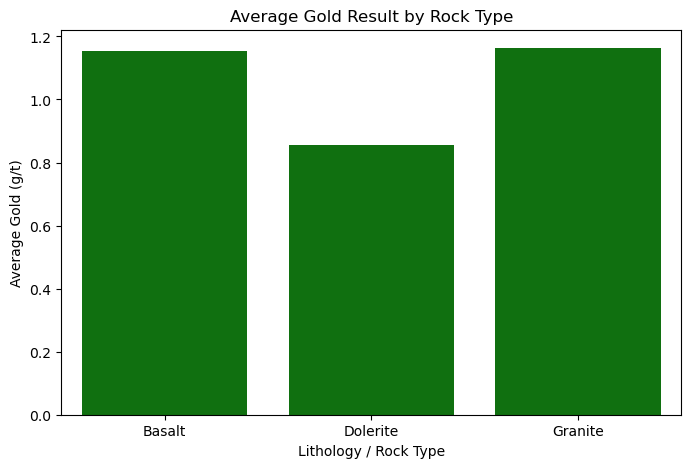

In [189]:
#Plot the average Au by the lithology
plt.figure(figsize = (8,5))
plt.title("Average Gold Result by Rock Type")
plt.ylabel ("Average Gold (g/t)")
plt.xlabel("Lithology / Rock Type")
sns.barplot (x= 'lithology', y = 'au_result', color= 'green', data = au_litho)
plt.show()
    

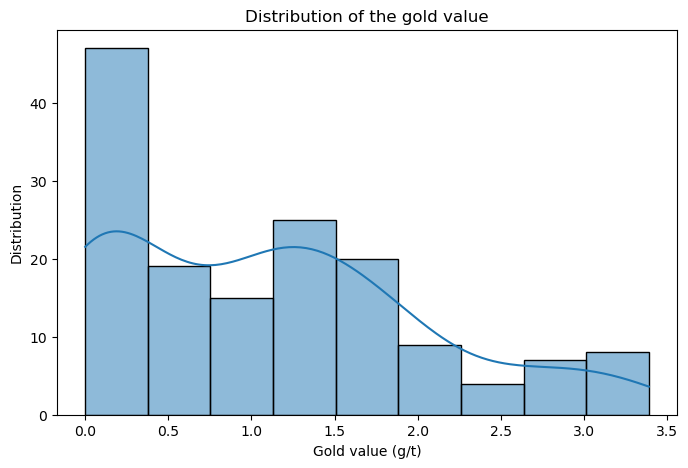

In [194]:
#What are distribution of the Gold
plt.figure( figsize =(8,5))
plt.title('Distribution of the gold value')
plt.xlabel ('Gold value (g/t)')
plt.ylabel('Distribution')
sns.histplot(data = geology, x= 'au_result', kde = True)
plt.show()

#Please  note that during the data cleaning, sopme of the Au were reported as negative, of which were replace with NAN

<Axes: title={'center': 'Gold distribution in a Granite'}, xlabel='au_result', ylabel='Count'>

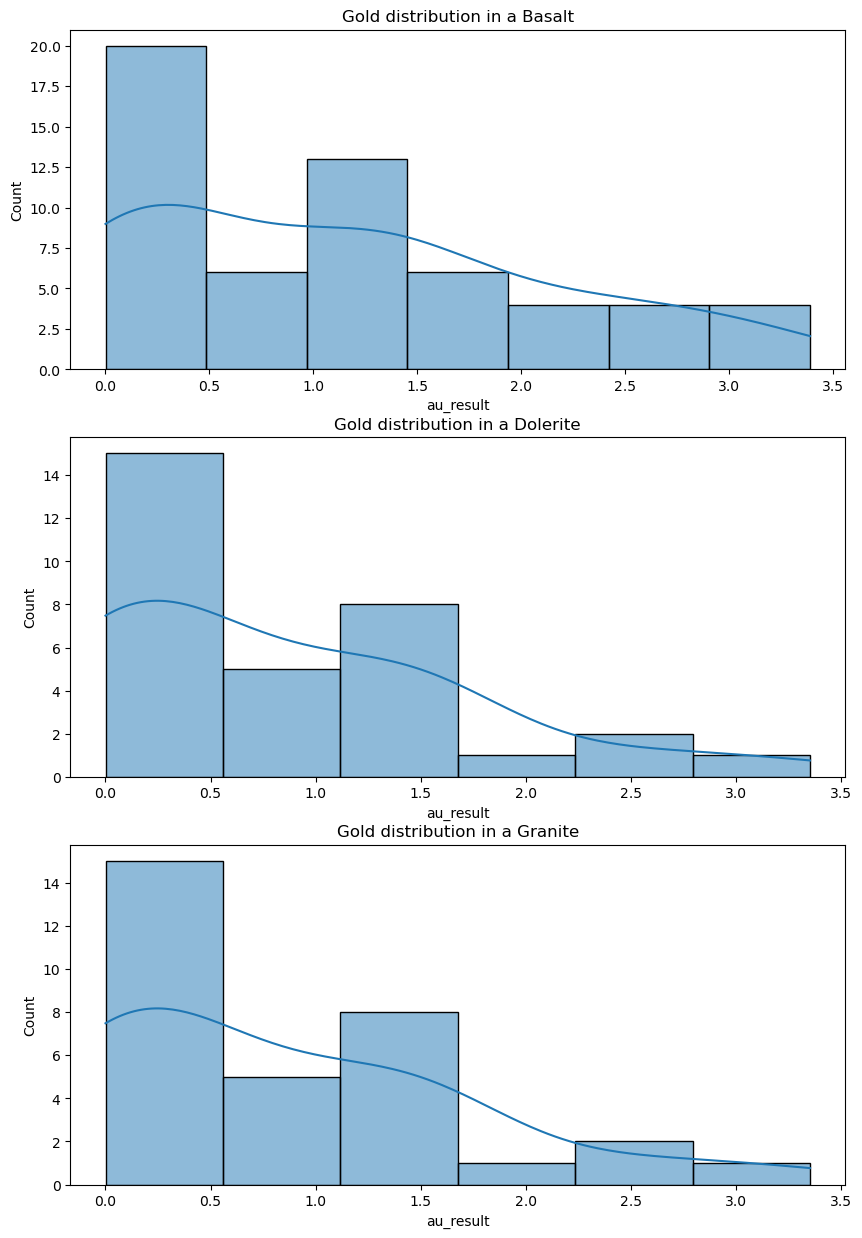

In [213]:
#Distribution of gold across the rock types

fig, axes = plt.subplots(3,1, figsize = (10,15))

#For the firstplot do a distribution by basalt
basalt_au = geology[geology['lithology'] == 'Basalt']
axes[0].set_title('Gold distribution in a Basalt')
sns.histplot( x= basalt_au['au_result'], kde =True, ax=axes[0])

#Distribution of a gold in a Dolerite
dolerite_au = geology[geology['lithology'] == 'Dolerite']
axes[1].set_title('Gold distribution in a Dolerite')
sns.histplot( x= dolerite_au['au_result'], kde =True, ax=axes[1])

#Distribution of a gold in a Granite
granite_au = geology[geology['lithology'] == 'Granite']
axes[2].set_title('Gold distribution in a Granite')
sns.histplot( x= dolerite_au['au_result'], kde =True, ax=axes[2])

#There is a consistent negative skewness of gold across all analytes

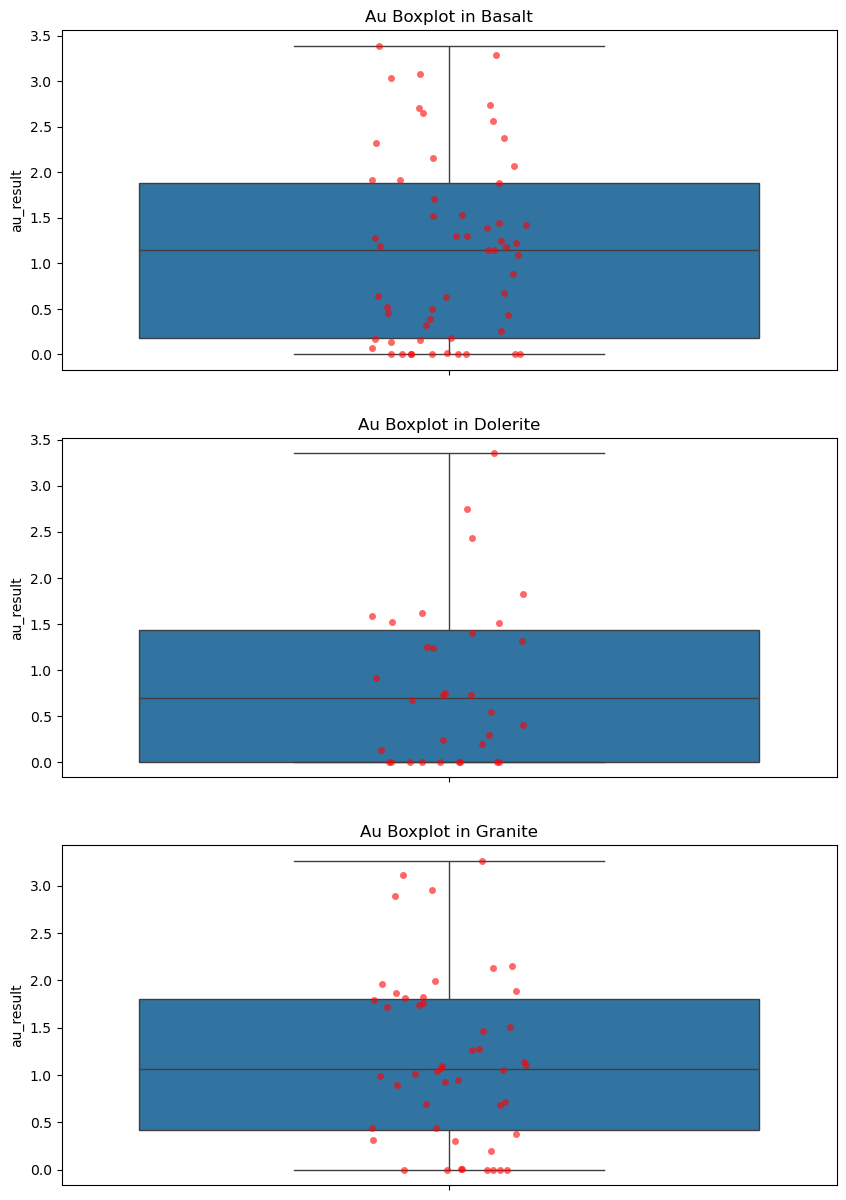

In [234]:
#Check out outliers in the dataset using the BoxPlot Diagram by the Lithology

fig, axes = plt.subplots(3,1, figsize = (10,15))
sns.boxplot(basalt_au['au_result'], ax = axes[0])
sns.stripplot(y=basalt_au['au_result'], ax=axes[0],
              color='red', alpha=0.6, jitter = True)
axes[0].set_title ('Au Boxplot in Basalt')

sns.boxplot(dolerite_au['au_result'], ax = axes[1])
axes[1].set_title ('Au Boxplot in Dolerite')
sns.stripplot(y = dolerite_au['au_result'], ax =axes[1],
              color='red', alpha = 0.6, jitter = True)

sns.boxplot(granite_au['au_result'], ax = axes[2])
sns.stripplot(y=granite_au['au_result'], ax = axes[2],
               color ='red', alpha = 0.6, jitter =True)
axes[2].set_title ('Au Boxplot in Granite')
plt.show()

In [191]:
#Correlation between the depth andthe  au

geology[['to_m', 'interval_m', 'au_result']].corr()

#There is no correlation between the au value and the depth of the borehole, implying that the rich zone can be intercepeted at an stage of the drillhole

,to_m,interval_m,au_result
to_m,1.000000,0.519491,-0.056666
interval_m,0.519491,1.000000,-0.055255
au_result,-0.056666,-0.055255,1.000000


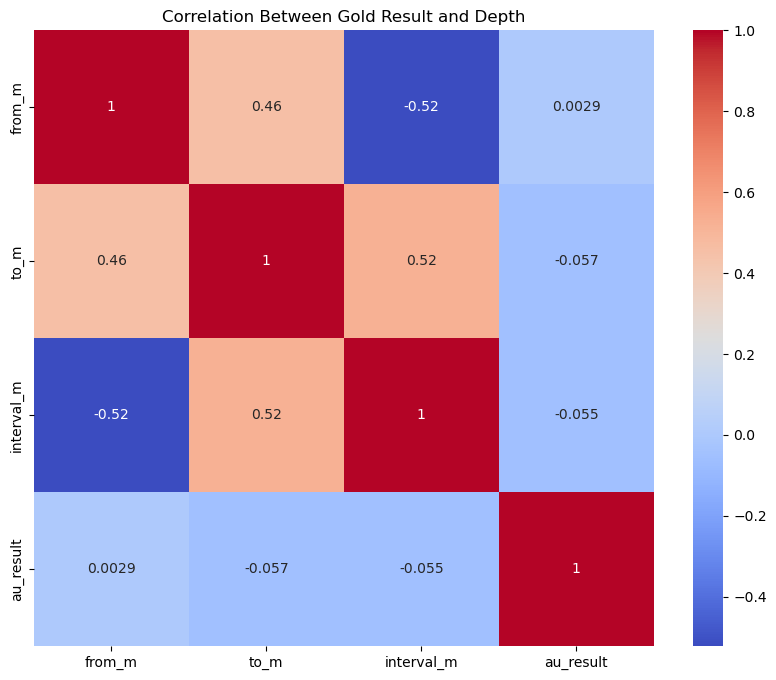

In [243]:
#Graphical correlation between the numeric variables

correlation = geology.corr(numeric_only= True)
plt.figure (figsize = (10,8))
plt.title('Correlation Between Gold Result and Depth')
sns.heatmap(corr,
           annot = True,
           cmap = 'coolwarm')
plt.show()  #This map shows poor correlation between the gold results with the depth 

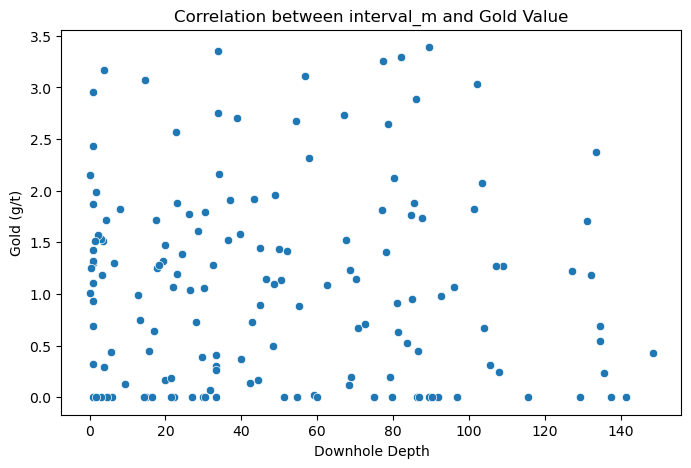

In [214]:
#View the correlation using scatter plot
plt.figure (figsize = (8,5))
plt.title ("Correlation between Interval_m and Gold Value")
plt.xlabel ('Downhole Depth')
plt.ylabel ('Gold (g/t)')
sns.scatterplot(x = 'interval_m', y ='au_result', data = geology)
plt.show()

In [201]:
#For the firstplot do a distribution by basalt
basalt_au = geology[geology['lithology'] = Basalt]

<class 'SyntaxError'>: cannot assign to subscript here. Maybe you meant '==' instead of '='? (<ipython-input-201-bba13626d0ab>, line 2)

In [202]:
basalt_au = geology[geology['lithology'] == 'Basalt']